<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/10_lqr_finite_horizon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finite horizon LQR

## 1. Discrete-Time Finite-Horizon LQR

In this problem, you will design and compare optimal controllers for a *discrete-time* double-integrator system
(a simple model of a robot joint's position and velocity) over a **finite time horizon**.


In [ ]:
import cvxpy as cp
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact
import functools
from typing import Callable, Tuple

### (a) Dynamics set up

Consider 1D double integrator dynamics, with position $x$, velocity $v$, and acceleration $a$. The *continuous time* dynamics are $ \ddot{x} = a $

### (a)(i) Write out the state-space dynamics of the 1D double integrator system.
What variables make up the state vector $\mathbf{x}=[\ldots]$, and control input $\mathbf{u}=[\ldots]$?

[Student response here]

### (a)(ii) What are the *discrete-time* dynamics?
Given the dynamics are considering are relatively simple, derive and write out the analytic form of the discrete time dynamics assuming zero-order-hold on the control input over timestep size $\Delta t$.

That is, carry out the integration.
$$\mathbf{x}_{k+1} = \mathbf{x}_k + \int_0^{\Delta t} f(\mathbf{x}(\tau + t_k), \mathbf{u}_k) d\tau$$


To avoid some confusion with $t$ representing the continuous time, and also $t$ to be the time step number as we used in class, we will denote the current time $t_k$ correspond to the time at timestep number $k$, and $\mathbf{x}_k = \mathbf{x}(t_k)$, $\mathbf{x}_{k+1} = \mathbf{x}(t_{k+1})$, $\mathbf{u}_k = \mathbf{u}(t_k)$, and $\mathbf{u}_{k+1} = \mathbf{u}(t_{k+1})$.


[student respons here]



### (a) (iii) Are the discrete time dynamics linear, control-affine, or nonlinear?

[student response here]


## (b) Setting up the finite horizon LQR problem
We wish to construct a controller that will stablize the system about the origin (zero position, zero velocity).
In this problem, we will set up the LQR problem, and compute the optimal linear feedback gain over a finite horizon.


### (b)(i) Setting up the dynamics
First, we need to define the linear dynamics for the system. Construct the $A$ and $B$ matrices corresponding to the discrete-time dynamics with timestep size $\Delta t = 0.1$ seconds.
If you found that the system was linear (from part (a)(iii)), then just write out the $A$ and $B$ matrices. Otherwise linearize about the origin.


In [ ]:
# [student response here]
dt = 0.1  # time step [s]
state_dim = 50  # state dimension # UPDATE ME
control_dim = 10  # control dimension # UPDATE ME

# UPDATE ME
A = jnp.zeros((state_dim, state_dim))
# UPDATE ME
B = jnp.zeros((state_dim, control_dim))


### (b)(ii) Set up the LQR parameters
Now, we need to set up the LQR cost parameters $Q$, $R$, and $Q_f$
\begin{aligned}
J(\mathbf{x}_0, \mathbf{u}_{0:N-1}) = \sum_{k=0}^{N-1} \left( \mathbf{x}_k^\top Q \mathbf{x}_k + \mathbf{u}_k^\top R \mathbf{u}_k \right)
\;+\;
\mathbf{x}_N^\top Q_f \mathbf{x}_N
\end{aligned}

Let's start off with values corresponding to:
- Penalize position error a lot more than velocity error over the horizon
- Small penalty on control effort
- Very high importance on being at the origin at the end of the horizon.

Choose a set of parameters that correspond to these desires.

In [ ]:
# [student response here]
Q = jnp.eye(state_dim)  # state cost matrix # UPDATE ME
R = jnp.eye(control_dim)  # control cost matrix # UPDATE ME
Qf = jnp.eye(state_dim)  # terminal cost # UPDATE ME

### (b)(iii) Perform the Riccati recursion
We should now have all the pieces in place to perform the Riccati recursion, to obtain $P_k$ and corresponding gain $K_k$ for each time step in the horizon.

Recall from lecture that the optimal finite-horizon feedback has the form $u_k = K_k x_k$,
where the gains $K_k$ come from a backward recursion on the cost-to-go matrices $P_k$.

You will complete the body of the function `discrete_time_riccati_backward`.  

For $k = N-1, \dots, 0$:

- $ P_N = Q_f $
- $ S_k = R + B^\top P_{k+1} B $
- $ F_k = B^\top P_{k+1} A $
- $ K_k = -S_k^{-1} F_k $
- $ P_k = Q + A^\top P_{k+1} A + A^\top P_{k+1} B K_k $

Implement the function and test it out!

In [ ]:
# [student response here]


def discrete_time_riccati_backward(
    A: jnp.ndarray,
    B: jnp.ndarray,
    Q: jnp.ndarray,
    R: jnp.ndarray,
    Qf: jnp.ndarray,
    n_timesteps: int,
):
    """
    Solve the discrete-time finite-horizon Riccati equations backwards in time.
    Args:
        A: System dynamics matrix.
        B: Control input matrix.
        Q: State cost matrix.
        R: Control cost matrix.
        Qf: Terminal state cost matrix.
        n_timesteps: Number of timesteps in the horizon.
    Returns:
        Ps: List of state cost-to-go matrices at each timestep. Size (n_timesteps + 1, n, n).
        Ks: List of optimal feedback gain matrices at each timestep. Size (n_timesteps, m, n).

    HINT: You may find jnp.linalg.solve useful for solving linear systems. Equivalent to x = A \ b in matlab.
    HINT: Due to numerical rounding errors, it is a good idea to symmetrize P at each step via P = 0.5 * (P + P.T)
    """
    Ks = []
    P = Qf
    Ps = [P]
    ###### YOUR CODE HERE ######

    ############################

    return Ps, Ks

<>:25: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-2718211576.py:25: SyntaxWarning: invalid escape sequence '\ '
  HINT: You may find jnp.linalg.solve useful for solving linear systems. Equivalent to x = A \ b in matlab.


In [ ]:
# run this cell to generate plots

# plot out the value function contours
n_timesteps = 25
Ps, Ks = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)


# feel free to remove the `@interact` decorator if it causes issues with PDF conversion
# you can just genreate plots for specific timesteps instead
@interact(timestep=(0, len(Ps) - 1))
def plot_value_function(timestep):
    P = Ps[timestep]
    X, V = jnp.meshgrid(jnp.linspace(-10, 10, 100), jnp.linspace(-10, 10, 100))
    states = jnp.concatenate([X.reshape(-1, 1), V.reshape(-1, 1)], axis=1).T
    Z = jax.vmap(lambda x: x.T @ P @ x)(states.T)
    Z = Z.reshape(X.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(X, V, Z, levels=20, cmap="viridis")
    plt.colorbar()
    plt.clim(0, 10000)
    plt.title("Value Function Contours")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.show()

interactive(children=(IntSlider(value=12, description='timestep', max=25), Output()), _dom_classes=('widget-in…

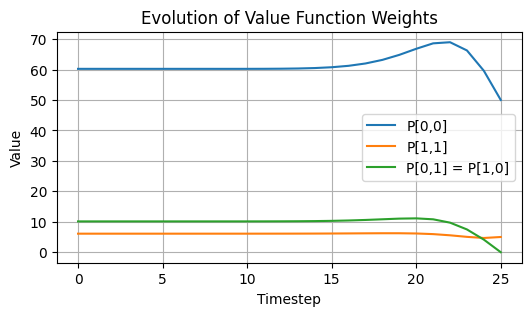

In [ ]:
# run this cell to generate a plot
# plot out the evolution of the value function weights
plt.figure(figsize=(6, 3))
plt.plot(jnp.arange(n_timesteps + 1), Ps[:, 0, 0], label="P[0,0]")
plt.plot(jnp.arange(n_timesteps + 1), Ps[:, 1, 1], label="P[1,1]")
plt.plot(jnp.arange(n_timesteps + 1), Ps[:, 0, 1], label="P[0,1] = P[1,0]")
plt.title("Evolution of Value Function Weights")
plt.xlabel("Timestep")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

### (b)(iv) Hmmm...I'm not sure if I did this right. How would I verify that my answer is correct?
Okay, so now, you wrote some code and produced some numbers, but you are not sure if the answer is correct. What can you do to verify that your implementation is correct?

Well, you remember that the value function represents the *cost-to-go*. That is, the future accumulated cost when following a particular policy.
So we should have

$$
V(\mathbf{x}_k,t_k)  = \mathbf{x}_N^TQ_f\mathbf{x}_N + \sum_{k=k}^{N-1} \mathbf{x}_k^TQ\mathbf{x}_k + \mathbf{u}_k^TR\mathbf{u}_k = \mathbf{x}_k^TP_k\mathbf{x}_k
$$

So let's use this fact to verify that our computed $P_k$ does indeed correspond to the cost-to-go when executing policy $\mathbf{u}_k=K_k\mathbf{x}_k$.

In [ ]:
# run this cell to generate the LQR policy

# run the Riccati backward to get Ps and Ks
Ps, Ks = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)


# get the LQR policy from extracting Ks at the given timestep
def lqr_policy(state, timestep):
    K = Ks[timestep]
    u = K @ state
    return u

In [ ]:
# [student response here]

def cost_to_go(
    current_state: jnp.ndarray,
    policy: Callable[[jnp.ndarray, int], jnp.ndarray],
    ϘRQf: Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray],
    current_timestep: int,
    max_timestep: int,
) -> float:
    """
    Compute the cost-to-go from the current state to the end of the horizon.
    Args:
        current_state: The current state vector.
        policy: A function that takes in a state and timestep and returns the control input.
        QRQf: Tuple of the state, control, and terminal cost matrices.
        current_timestep: The current timestep index.
        max_timestep: The maximum timestep index (horizon length).
    Returns:
        total_cost: The total cost-to-go from the current state. Size ().
    """
    Q, R, Qf = ϘRQf
    total_cost = 0
    ###### YOUR CODE HERE ######

    ############################
    return total_cost

In [ ]:
# run this cell to compare your cost-to-go implementation with the computed value function
# this will verify that the cost-to-go matches the value function at several states and timesteps

X, V = jnp.meshgrid(jnp.linspace(-10, 10, 100), jnp.linspace(-10, 10, 100))
states = jnp.concatenate([X.reshape(-1, 1), V.reshape(-1, 1)], axis=1)
n_discrepancies = 0
for current_timestep in range(n_timesteps):
    cost_to_go_partial = functools.partial(
        cost_to_go,
        policy=lqr_policy,
        ϘRQf=(Q, R, Qf),
        current_timestep=current_timestep,
        max_timestep=n_timesteps,
    )
    cost_to_go_rollout = jax.vmap(cost_to_go_partial)(states)
    cost_to_go_P = jax.vmap(lambda x: x.T @ Ps[current_timestep] @ x)(states)
    values_match = jnp.allclose(cost_to_go_rollout, cost_to_go_P)
    if not values_match:
        print(f"Values do not match at timestep {current_timestep}")
        n_discrepancies += 1
if n_discrepancies == 0:
    print("All values match!!!")


All values match!!!


Great! Assuming everything looks good so far -- you have just implemented discrete-time LQR!

### (c) Now, let's rollout several trajectories using our LQR controller
Implement the `rollout_dlqr` function to generate the sequence of control and states.



In [ ]:
# [student response here]
def rollout_dlqr(
    initial_state: jnp.ndarray,
    dynamics_AB: Tuple[jnp.ndarray, jnp.ndarray],
    K_seq: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Rollout the discrete-time LQR controller over the finite horizon.
    Args:
        initial_state: The initial state vector.
        dynamics_AB: A tuple (A, B) of system dynamics matrices.
        K_seq: Sequence of feedback gain matrices for each timestep.
    Returns:
        state_traj: State trajectory over the horizon. Size (T+1, n).
        control_traj: Control trajectory over the horizon. Size (T, m).
    """

    A, B = dynamics_AB
    ###### YOUR CODE HERE ######

    ############################

In [ ]:
# set up the LQR problem again (in case you want to try out different values)
Q = jnp.eye(state_dim) * 10  # state cost matrix  # UPDATE ME
R = jnp.eye(control_dim)  # control cost matrix # UPDATE ME
Qf = jnp.eye(state_dim) * 50  # terminal cost # UPDATE ME



# compute the Riccati backward to get Ps and Ks (again)
n_timesteps = 25  # Feel free to change
Ps, Ks = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)


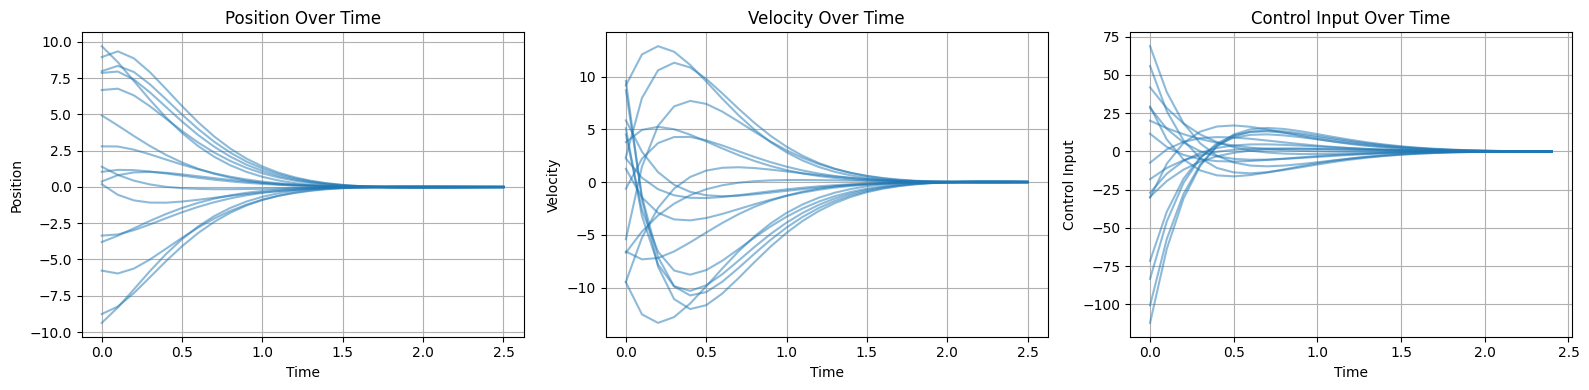

In [ ]:
# Run this cell to execute your function with some initial states, and plot the results

# sample multiple initial states
n_samples = 16
limits = 10  # feel free to change to adjust spread of initial states
initial_states = jax.random.uniform(
    jax.random.PRNGKey(0), (n_samples, 2), minval=-limits, maxval=limits
)

dynamics_AB = (A, B)
state_trajectory, control_trajectory = jax.vmap(rollout_dlqr, in_axes=(0, None, None))(
    initial_states, dynamics_AB, Ks
)


# plotting trajectories
time_x = jnp.arange(Ks.shape[0] + 1) * dt
time_u = jnp.arange(Ks.shape[0]) * dt

plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.plot(time_x, state_trajectory[:, :, 0].T, alpha=0.5, color="tab:blue")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Position Over Time")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(time_x, state_trajectory[:, :, 1].T, alpha=0.5, color="tab:blue")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocity Over Time")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(time_u, control_trajectory[:, :, 0].T, alpha=0.5, color="tab:blue")
plt.xlabel("Time")
plt.ylabel("Control Input")
plt.title("Control Input Over Time")
plt.tight_layout()
plt.grid()


### (d)(i) The importance of time in finite-horizon LQR
Notice that the LQR control gain $K_k$ is indexed by time. You should use the $K_k$ corresponding to that time step.
Let's take a closer look at the impact of having $K_k$ be time-varying.

Consider a new LQR problem, with
$$
Q = I_n, \: R = 0.1I_m, Q_f = 50I_n
$$

Suppose you start "far" from the origin, e.g., $\mathbf{x}_0 = [10.0, 5.0]^T$. Consider the following two cases:

(a) We still have 25 timesteps to go. i.e., we have plenty of time to make it to the origin.

(b) We only have 5 timesteps left of our horizon to make it to the end. i.e., we don't have a lot of time to make it to the origin.

Let $\mathbf{u}_a = K_a\mathbf{x}_0$ be the first case, and $\mathbf{u}_b = K_b\mathbf{x}_0$ be the second case, where $K_a$, $K_b$ corresponds to the appropriate gain for each of the cases, respectively.
Before running any code, in your own words, describe how you may expect $\mathbf{u}_a$ to compare with $\mathbf{u}_b$.

[student response here]

In [ ]:
# run this cell to check your solution

Q = jnp.eye(state_dim)  # state cost matrix
R = jnp.eye(control_dim) * 0.1  # control cost matrix
Qf = jnp.eye(state_dim) * 50.0  # terminal cost


Ps, Ks = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)
n_remaining = 5
Ka, Kb = Ks[0], Ks[-n_remaining]
initial_state = jnp.array([10.0, 5.0])
print(f"u_a={(Ka @ initial_state).item():.3f}, u_b={(Kb @ initial_state).item():.3f}")


u_a=-44.021, u_b=-81.452


### (d)(ii) What happens if $R$ increased?
Now consider the same problem as above, but we increase $R$, say to $R=10I_m$.
Before running any code, in your own words, describe how $\mathbf{u}_a$ compares to $\mathbf{u}_b$.

[student response here]

In [ ]:
# run this cell to check your solution
Q = jnp.eye(2)  # state cost matrix
R = jnp.eye(1) * 10  # control cost matrix
Qf = jnp.eye(2) * 50.0  # terminal cost

Ps, Ks = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)
n_remaining = 5
Ka, Kb = Ks[0], Ks[-n_remaining]
initial_state = jnp.array([10.0, 5.0])
print(f"u_a={(Ka @ initial_state).item():.3f}, u_b={(Kb @ initial_state).item():.3f}")


u_a=-9.098, u_b=-4.633


# 2. Solving the LQR problem using convex optimization problem
Instead of using the Bellman equation to solve for the optimal LQR controller for all states and all time, we could instead just solve the LQR problem directly by framing it as an convex optimization problem.
In this problem, we solve the LQR problem using `cvxpy` and compare our solution with the solution from performing the Riccati recursion.


We now solve the *same* finite-horizon control problem as a convex QP in `cvxpy`.
Implement the `solve_lqr_cvx` function below.

In [ ]:
# [student response here]
def solve_lqr_cvx(
    dynamics_AB: Tuple[jnp.ndarray, jnp.ndarray],
    Q: jnp.ndarray, R: jnp.ndarray,
    Qf: jnp.ndarray,
    initial_state: jnp.ndarray, n_timesteps: int, umin=None, umax=None):
    """
    Solve the finite-horizon optimal control problem via cvxpy.
    Args:
        dynamics_AB: A tuple (A, B) of system dynamics matrices.
        Q: State cost matrix.
        R: Control cost matrix.
        Qf: Terminal state cost matrix.
        initial_state: The initial state vector.
        n_timesteps: Number of timesteps in the horizon.
        umin: if not None, enforce u_k >= umin (hard constraint).
        umax: if not None, enforce u_k <= umax (hard constraint).
    Returns:
        optimal_states: optimal state trajectory as an array with shape (n_timesteps+1, 2).
        optimal_controls: optimal control sequence as an array with shape (n_timesteps, 1).
    """

    A, B = dynamics_AB
    n, m = B.shape
    states = cp.Variable((n_timesteps + 1, n))
    controls = cp.Variable((n_timesteps, m))
    ###### YOUR CODE HERE ######

    ############################
    return states.value, controls.value


### (b) Compare the solution CVXPY with your rollout from `rollout_dlqr`.
Verify that your solution should match (to some degree of floating point precision)


In [ ]:
# Run this cell to check your solution
Q = jnp.eye(2)  # state cost matrix
R = jnp.eye(1) * 5  # control cost matrix
Qf = jnp.eye(2) * 50.0  # terminal cost

initial_state = jnp.array([10.0, 5.0])
n_timesteps = 25
dynamics_AB = (A, B)

#  compute solution via cvxpy
states_cvx, controls_cvx = solve_lqr_cvx(dynamics_AB, Q, R, Qf, initial_state, n_timesteps)

# compute solution via riccati
Ps, K_dlqr = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)
states_riccati, control_riccati = rollout_dlqr(
    initial_state,
    dynamics_AB,
    K_dlqr,
)

#  compare solutions
atol = 1e-6
print("States match:", jnp.allclose(states_cvx, states_riccati, atol=atol))
print("Controls match:", jnp.allclose(controls_cvx, control_riccati, atol=atol))

States match: True
Controls match: True


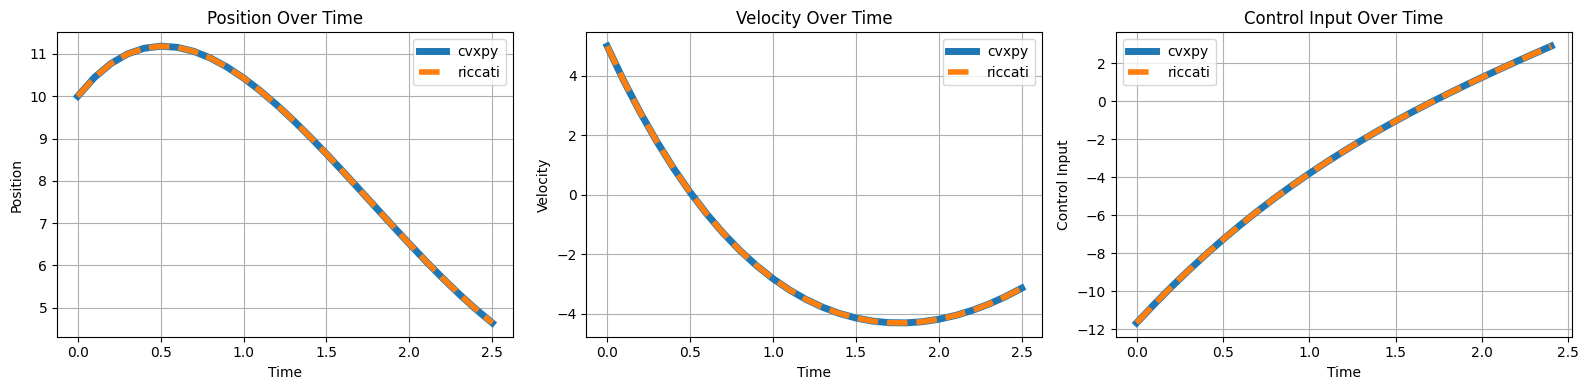

In [ ]:
# Run this cell to plot your solution
# plotting trajectories
time_x = jnp.arange(Ks.shape[0] + 1) * dt
time_u = jnp.arange(Ks.shape[0]) * dt

plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.plot(time_x, states_cvx[:, 0].T, linewidth=5, color="tab:blue", label="cvxpy")
plt.plot(time_x, states_riccati[:, 0].T, '--', linewidth=4, color="tab:orange", label="riccati")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Position Over Time")
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(time_x, states_cvx[:, 1].T, linewidth=5, color="tab:blue", label="cvxpy")
plt.plot(time_x, states_riccati[:, 1].T, '--', linewidth=4, color="tab:orange", label="riccati")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Velocity Over Time")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(time_u, controls_cvx[:, 0].T, linewidth=5, color="tab:blue", label="cvxpy")
plt.plot(time_u, control_riccati[:, 0].T, '--',  linewidth=4,color="tab:orange", label="riccati")
plt.xlabel("Time")
plt.ylabel("Control Input")
plt.title("Control Input Over Time")
plt.tight_layout()
plt.legend()
plt.grid()

# 3. Incorporating control constraints
Notice that the standard LQR problem does not explicitly consider control constraints. Indeed, we find that the computed control can often exceed the allowable control limits of our system. In fact, since the optimal controller is a *linear controller*, the further away you are from the origin, the larger the control input required.
As such, we need to restrict the max/min value of the control.

We'll explore three strategies:

1. **Soft penalty:**  
   - Increase `R` to discourage large control effort.
   - Intuition: "Please don't push too hard."

2. **Hard constraint:**  
   - Keep original `R`, but enforce $|u_k| \le u_{\max}$ directly in the cvxpy problem using `umax`.
   - Intuition: "You are physically not allowed to exceed this value."

3. **Naive clipping:**  
   - Take the *unconstrained* LQR control solution and clip it: $u_k^{\text{clipped}} = \text{clip}(u_k^\mathrm{LQR},\,-u_{\max},\,u_{\max})$.


### (a) Implement the `rollout_dlqr_clipped` function.
This should be a minor change to the `rollout_dlqr` function.

In [ ]:
# [student response here]
def rollout_dlqr_clipped(
    initial_state: jnp.ndarray,
    dynamics_AB: Tuple[jnp.ndarray, jnp.ndarray],
    K_seq: jnp.ndarray,
    umin: float,
    umax: float,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Rollout the discrete-time LQR controller over the finite horizon.
    Args:
        initial_state: The initial state vector.
        dynamics_AB: A tuple (A, B) of system dynamics matrices.
        K_seq: Sequence of feedback gain matrices for each timestep.
    Returns:
        state_traj: State trajectory over the horizon. Size (horizon+1, n).
        control_traj: Control trajectory over the horizon. Size (horizon, m).
    """

    A, B = dynamics_AB
    ###### YOUR CODE HERE ######

    ############################

### (b) Compare the results of each of the approaches.



In [ ]:
# Run this cell to check your solution

# Feel free to change the values of the parameters.
umax = 1.0
umin = -1.0
Q = jnp.eye(2)  # state cost matrix
R = jnp.eye(1) * 0.1  # control cost matrix
Qf = jnp.eye(2) * 5.0  # terminal cost

# initial state and horizon
initial_state = jnp.array([10.0, -1.0])
n_timesteps = 50

# option 1: Soft penalty
R_soft = jnp.eye(1) * 150.0  # UPDATE ME so that the controls don't exceed the limits
Ps, K_dlqr = discrete_time_riccati_backward(A, B, Q, R_soft, Qf, n_timesteps)
states_soft, control_soft = rollout_dlqr(initial_state, dynamics_AB, K_dlqr)


# option 2: Hard constraints using CVXPY
states_cvx, control_cvx = solve_lqr_cvx(
    dynamics_AB, Q, R, Qf, initial_state, n_timesteps, umin, umax
)

# option 3: Hard constraints using Riccati with clipping
Ps, K_dlqr = discrete_time_riccati_backward(A, B, Q, R, Qf, n_timesteps)
states_clip, control_clip = rollout_dlqr_clipped(
    initial_state, dynamics_AB, K_dlqr, umin, umax
)

# function to check if controls are at limits
def at_control_limits(timestep):
    u_soft = control_soft[timestep, 0]
    u_cvx = control_cvx[timestep, 0]
    u_clip = control_clip[timestep, 0]
    return (jnp.isclose(u_soft, umin) or jnp.isclose(u_soft, umax),
            jnp.isclose(u_cvx, umin) or jnp.isclose(u_cvx, umax),
            jnp.isclose(u_clip, umin) or jnp.isclose(u_clip, umax))

In [ ]:
def plot_compare_constraints(
    time_x,
    time_u,
    states_soft,
    control_soft,
    states_hard,
    control_hard,
    states_clip,
    control_clip,
    umin,
    umax,
):
    """
    Compare these strategies on one set of plots:
    - Soft penalty (big R)
    - Hard constraint (|u| <= umax)
    - Clipped LQR (|u| <= umax)

    Also overlays ±umax on the control plot as dashed lines.
    """

    # Position / Velocity
    plt.figure(figsize=(16, 4))

    # Position
    plt.subplot(1, 3, 1)
    plt.title("Position with different strategies")
    plt.plot(time_x, states_soft[:, 0], label="Soft penalty")
    plt.plot(time_x, states_hard[:, 0], label="Hard constraint")
    plt.plot(time_x, states_clip[:, 0], label="Clipped LQR")
    plt.xlabel("time [s]")
    plt.ylabel("position")
    plt.legend()
    plt.grid(True)

    # Velocity
    plt.subplot(1, 3, 2)
    plt.title("Velocity with different strategies")
    plt.plot(time_x, states_soft[:, 1], label="Soft penalty")
    plt.plot(time_x, states_hard[:, 1], label="Hard constraint")
    plt.plot(time_x, states_clip[:, 1], label="Clipped LQR")
    plt.xlabel("time [s]")
    plt.ylabel("velocity")
    plt.grid(True)

    # Control comparison
    plt.subplot(1, 3, 3)
    plt.title("Control input comparison")
    plt.plot(time_u, control_soft[:, 0], label="Soft penalty")
    plt.plot(time_u, control_hard[:, 0], label="Hard constraint")
    plt.plot(time_u, control_clip[:, 0], label="Clipped LQR")

    # actuator limit lines
    plt.plot(
        time_u, umax * jnp.ones_like(time_u), "k--", linewidth=1.0, label="u limits"
    )
    plt.plot(time_u, umin * jnp.ones_like(time_u), "k--", linewidth=1.0)
    plt.xlabel("time [s]")
    plt.ylabel("u (acceleration)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

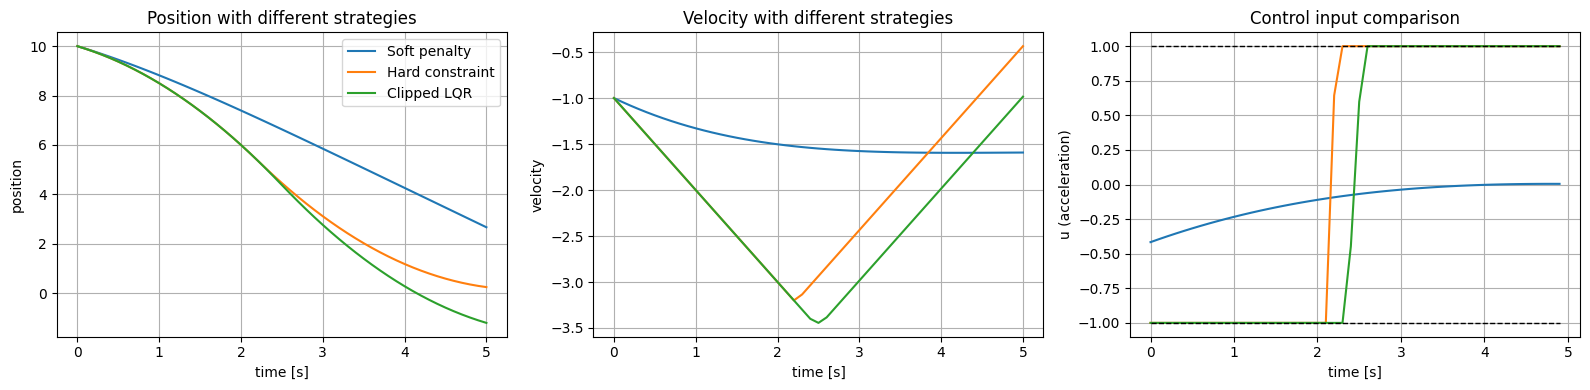

In [ ]:
time_x = jnp.arange(n_timesteps + 1) * dt
time_u = jnp.arange(n_timesteps) * dt

plot_compare_constraints(
    time_x,
    time_u,
    states_soft,
    control_soft,
    states_cvx,
    control_cvx,
    states_clip,
    control_clip,
    umin=umin,
    umax=umax,
)

In [ ]:
# OPTIONAL: Run this cell to see an animation of the different strategies
# Red border indicates when control is at limits
# But remove the output to avoid issues with exporting notebook as PDF
import matplotlib.animation as animation
from IPython.display import HTML


fig, ax = plt.subplots(figsize=(15, 4))


def update(frame):
    at_limits = at_control_limits(frame)
    ax.clear()
    ax.scatter(
        states_soft[frame, 0],
        -0.5,
        label="Soft penalty",
        color="blue",
        zorder=0,
        alpha=0.5,
        s=200,
        edgecolor="r" if at_limits[0] else "white",
        linewidth=3,
    )
    ax.scatter(
        states_cvx[frame, 0],
        0,
        label="Hard constraint (CVX)",
        color="orange",
        zorder=0,
        alpha=0.5,
        s=200,
        edgecolor="r" if at_limits[1] else "white",
        linewidth=3,
    )
    ax.scatter(
        states_clip[frame, 0],
        0.5,
        label="Clipped LQR",
        color="green",
        zorder=0,
        alpha=0.5,
        s=200,
        edgecolor="r" if at_limits[2] else "white",
        linewidth=3,
    )
    ax.grid(alpha=0.3)
    ax.legend(ncols=3)
    ax.set_xlim(-5, 11)
    ax.set_ylim(-2, 2)
    # ax.axis("equal")
    return []


ani = animation.FuncAnimation(fig, update, frames=range(n_timesteps), interval=100)
plt.close(fig)
HTML(ani.to_jshtml())

### (c) Which approach do you think gives the optimal solution? Explain your answer.

[student answer here]

In [ ]:
# Run this code afterwards to check your solution
# use your `cost_to_go` function you implemented earlier to verify your answer
c2g_soft = cost_to_go(initial_state, lambda state, t: control_soft[t], (Q, R, Qf), 0, n_timesteps)
c2g_cvx = cost_to_go(initial_state, lambda state, t: control_cvx[t], (Q, R, Qf), 0, n_timesteps)
c2g_clip = cost_to_go(initial_state, lambda state, t: control_clip[t], (Q, R, Qf), 0, n_timesteps)
print(f"Cost-to-go Soft penalty: {c2g_soft:.3f}")
print(f"Cost-to-go Hard constraint (CVX): {c2g_cvx:.3f}")
print(f"Cost-to-go Clipped LQR: {c2g_clip:.3f}")


Cost-to-go Soft penalty: 2577.208
Cost-to-go Hard constraint (CVX): 1950.606
Cost-to-go Clipped LQR: 1991.177


# 4. Continuous-Time Finite-Horizon LQR

We now consider the continuous-time system

\begin{aligned}
\dot{x}(t) = A x(t) + B u(t), \quad t \in [0, T],
\end{aligned}

with state $x(t) \in \mathbb{R}^n$ and control $u(t) \in \mathbb{R}^m$.

We choose a control signal $u(\cdot)$ to minimize the finite-horizon quadratic cost

\begin{aligned}
J = \int_0^T \left( x(t)^\top Q x(t) + u(t)^\top R u(t) \right) \, dt
\;+\;
x(T)^\top Q_f x(T),
\end{aligned}

with
- $Q \succeq 0,$
- $R \succ 0,$
- $Q_f \succeq 0.$

The optimal value function takes the quadratic form
\begin{aligned}
V(t, x) = x^\top P(t) x,
\end{aligned}
where \(P(t)\) is now time-varying.

By plugging this into the Hamilton–Jacobi–Bellman equation and eliminating $u(t)$, we get the **continuous-time Riccati differential equation**:

\begin{aligned}
-\dot{P}(t)
= A^\top P(t) + P(t) A - P(t) B R^{-1} B^\top P(t) + Q,
\quad
P(T) = Q_f.
\end{aligned}

Equivalently, we can write

\begin{aligned}
\dot{P}(t)
= -A^\top P(t) - P(t) A + P(t) B R^{-1} B^\top P(t) - Q,
\quad
P(T) = Q_f.
\end{aligned}

Even though that looks like a forward ODE in $t$, we must integrate it **backward in time** with terminal condition $P(T)=Q_f$, from $t=T$ down to $t=0$.
This is the continuous-time analog of the discrete-time recursion $P_N, P_{N-1}, \ldots, P_0$.

After we obtain $P(t)$, the optimal feedback control law is

\begin{aligned}
u^*(t) = K(t)\,x(t),
\quad \text{where}\quad
K(t) = -R^{-1} B^\top P(t).
\end{aligned}




In [ ]:
# Run this cell to set up problem:: continuous-time double integrator parameters
horizon = 5.0  # horizon length (seconds)

A = jnp.array([[0.0, 1.0], [0.0, 0.0]])
B = jnp.array([[0.0], [1.0]])

Q = jnp.diag(jnp.array([5.0, 0.5]))  # penalize position error >> velocity error
R = jnp.array([[0.5]])  # penalize control effort
Qf = jnp.diag(jnp.array([10.0, 2.0]))  # terminal cost: end near p=0, v=0

x0 = jnp.array([2.0, 0.0])  # initial condition at t=0: p(0)=2, v(0)=0


### (a) Integrate the continuous-time Riccati ODE backward

We will need to integrate the matrix ODE for $P(t)$ **backward** from $t = T$ to $t = 0$.
We will use the `solve_ivp` from `scipy.integrate` to perform the integration. However, the `solve_ivp` function expects an ODE function to be in vector form, rather than a matrix.
To do this, we will store $P(t)$ in flattened form.

Fill in the `riccati_ode` function and run the following cells to solve for $P(t)$ and visualize it.




In [ ]:
# [student response here]
def riccati_ode(
    time: float,
    P_flat: jnp.ndarray,
    A: jnp.ndarray,
    B: jnp.ndarray,
    Q: jnp.ndarray,
    R: jnp.ndarray,
) -> jnp.ndarray:
    """
    Continuous-time Riccati differential equation.
    Args:
        time: Current time (not used, but required by solve_ivp).
        P_flat: Flattened state cost-to-go matrix P.
        A: System dynamics matrix.
        B: Control input matrix.
        Q: State cost matrix.
        R: Control cost matrix.
    Returns:
        dPdt_flat: Flattened time derivative of P. Size (n*n,).
    """

    ###### YOUR CODE HERE ######

    ############################
    return dPdt_flat

In [ ]:
# Run this cell to solve the continuous-time Riccati equation backward in time
# integrate backward Riccati: from t = horizon down to t = 0
t_span = (horizon, 0.0)

# initial condition for P at t = horizon is P(horizon) = Qf
P_T_flat = Qf.flatten()

# set up partial function for ODE solver
riccati_ode_partial = functools.partial(riccati_ode, A=A, B=B, Q=Q, R=R)

# solve the Riccati ODE
sol_P = solve_ivp(
    fun=lambda t, Pvec: riccati_ode_partial(t, Pvec),
    t_span=t_span,
    y0=P_T_flat,
    dense_output=True,
    rtol=1e-6,
    atol=1e-8,
)


In [ ]:
# Run this cell to evaluate P(t) on a time grid and plot value function contours
# create time grid to evaluate P(t) at several time points
num_samples = 200
times = jnp.linspace(0.0, horizon, num_samples)

# Evaluate P(t) for each t on the grid
state_dim = A.shape[0]
Ps = []
for ti in times:
    Pt_flat = sol_P.sol(ti)  # shape (n*n,)
    Ps.append(Pt_flat.reshape((state_dim, state_dim)))
Ps = jnp.stack(Ps, axis=0)  # shape (num_samples, n, n)


# plot out the value function contours
# feel free to remove the @interact if it causes issues with exporting notebook as PDF
@interact(timestep=(0, len(Ps) - 1))
def plot_value_function(timestep):
    P = Ps[timestep]
    X, V = jnp.meshgrid(jnp.linspace(-10, 10, 100), jnp.linspace(-10, 10, 100))
    states = jnp.concatenate([X.reshape(-1, 1), V.reshape(-1, 1)], axis=1).T
    Z = jax.vmap(lambda x: x.T @ P @ x)(states.T)
    Z = Z.reshape(X.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(X, V, Z, levels=20, cmap="viridis")
    plt.colorbar()
    plt.title("Value Function Contours")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.show()


interactive(children=(IntSlider(value=99, description='timestep', max=199), Output()), _dom_classes=('widget-i…

### (b) Compute the feedback gain $K(t)$ and inspect its magnitude

Once we have \(P(t)\), the optimal feedback law is

\begin{aligned}
u(t) = K(t)\, x(t),
\quad
K(t) = -R^{-1} B^\top P(t).
\end{aligned}

We'll now extract \(K(t)\) from every stored \(P(t)\).

Implement the functions below. Explain why does K(t) tend to get larger as $t \to T^-$ ?  


[student response here]

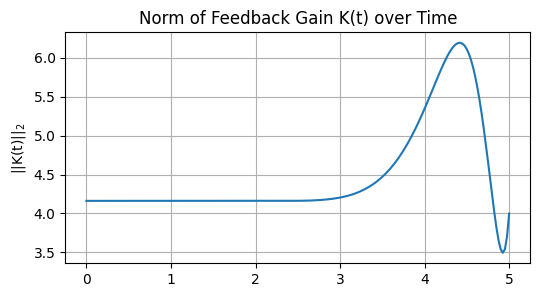

In [ ]:
# [student response here]
# function to compute K from P and plot its norm over time
def compute_K_from_P(P_t: jnp.ndarray, B: jnp.ndarray, R: jnp.ndarray):
    """
    Compute the optimal feedback gain K_t from the cost-to-go matrix P_t.
    Args:
        P_t: State cost-to-go matrix at time t.
        B: Control input matrix.
        R: Control cost matrix.
    Returns:
        K_t: Optimal feedback gain matrix at time t. Size (m, n).
    """
    ###### YOUR CODE HERE ######

    ############################
    return K_t

# compute K(t) for each P(t) and plot its norm over time
Ks = jax.vmap(compute_K_from_P, in_axes=(0, None, None))(Ps, B, R)
Ks_norm = jnp.linalg.norm(Ks, axis=-1).squeeze()
plt.figure(figsize=(6, 3))
plt.plot(times, Ks_norm)
plt.title("Norm of Feedback Gain K(t) over Time")
plt.ylabel(r"||K(t)||$_2$")
plt.grid()

### (c) Simulate the closed-loop system and interpret
We will compute the closed-loop dynamics and use the `solve_ivp` function to simulate the dynamics given initial conditions.

In [ ]:
# [student response here]
def closed_loop_dynamics(
    time: float,
    state: jnp.ndarray,
    A: jnp.ndarray,
    B: jnp.ndarray,
    R: jnp.ndarray,
    Psol: jnp.ndarray,
) -> jnp.ndarray:
    """
    Closed-loop dynamics under optimal LQR control.
    Args:
        time: Current time.
        state: Current state vector.
        A: System dynamics matrix.
        B: Control input matrix.
        R: Control cost matrix.
        Psol: Solution object from solve_ivp for P(t).
    Returns:
        dstate_dt: Time derivative of the state vector.
    """
    ###### YOUR CODE HERE ######

    ############################
    return dstate_dt



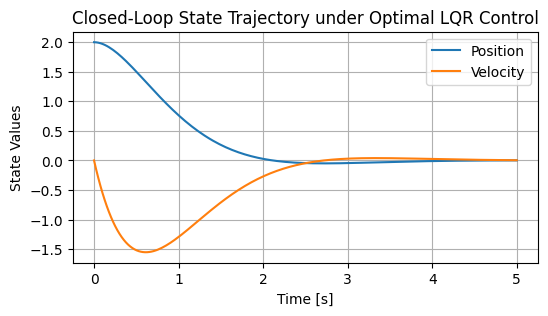

In [ ]:
# Run this cell to simulate the closed-loop system from an initial condition using `solve_ivp`
horizon = 5.0
initial_state = jnp.array([2.0, 0.0])
solution = solve_ivp(
    fun=closed_loop_dynamics,
    t_span=(0.0, horizon),
    y0=initial_state,
    args=(A, B, R, sol_P.sol),
    dense_output=True,
    rtol=1e-6,
    atol=1e-8,
)
times = jnp.linspace(0.0, horizon, 200)
trajectory = solution.sol(times).T
plt.figure(figsize=(6, 3))
plt.plot(times, trajectory[:, 0])
plt.plot(times, trajectory[:, 1])
plt.grid()
plt.title("Closed-Loop State Trajectory under Optimal LQR Control")
plt.xlabel("Time [s]")
plt.ylabel("State Values")
plt.legend(["Position", "Velocity"])